<a href="https://colab.research.google.com/github/epesh22/Intraday-Liquidity-Risk-VWAP-Execution-Model/blob/main/crack_spread_trading_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3-2-1 Crack Spread Trading Strategy
### Refinery Margin Mean-Reversion — Institutional Execution Framework

---

## Overview

The **crack spread** is the gross refining margin — the difference between the market value of refined petroleum products and the cost of the crude oil used to produce them. It is one of the most actively traded spreads in energy markets, used by refiners to hedge margins and by trading desks to speculate on dislocations.

This notebook implements a complete **3-2-1 crack spread mean-reversion trading strategy**, grounded in the economic theory of refinery economics and the statistical properties of commodity spreads.

### The 3-2-1 Formula

The **3-2-1 crack spread** models the output of a simplified refinery:
- **Buy** 3 barrels of WTI crude oil
- **Sell** 2 barrels of RBOB gasoline
- **Sell** 1 barrel of Ultra-Low Sulfur Diesel (heating oil proxy)

$$\text{Crack Spread} = \frac{2 \times P_{\text{RBOB}} \times 42 + 1 \times P_{\text{HO}} \times 42}{3} - P_{\text{WTI}}$$

where prices for RBOB and Heating Oil are in **\$/gallon** (multiply by 42 gal/barrel to convert), and WTI is in **\$/barrel**. The result is the **gross refining margin per barrel of crude processed**.

### Why Mean-Reversion Works

The crack spread is structurally mean-reverting due to a natural economic feedback loop:
- **Wide spread** → refiners run at full capacity → more product floods market → prices fall → spread narrows
- **Narrow spread** → refiners cut runs or shut down → product supply tightens → prices rise → spread widens

This feedback mechanism is what justifies a mean-reversion trading strategy — it is economically grounded, not just statistically observed.

### Notebook Structure

| Section | Content |
|---------|--------|
| **1. Setup** | Imports, configuration |
| **2. Data Acquisition** | WTI, RBOB, Heating Oil futures prices |
| **3. Crack Spread Calculation** | Unit conversion, 3-2-1 formula |
| **4. Exploratory Analysis** | Seasonality, distribution, autocorrelation |
| **5. Ornstein-Uhlenbeck Model** | Calibrate mean-reversion process |
| **6. Signal Generation** | Z-score signals with seasonal adjustment |
| **7. Backtest Engine** | Entry/exit rules, position sizing, costs |
| **8. Performance Analytics** | Sharpe, Sortino, drawdown, hit rate |
| **9. Risk Analysis** | VaR, stress tests, scenario analysis |
| **10. Results & Conclusions** | Summary report |

### Key References
- Geman, H. (2005). *Commodities and Commodity Derivatives.* Wiley Finance.
- Schwartz, E. (1997). *The Stochastic Behavior of Commodity Prices.* Journal of Finance.
- Cortazar, G. & Schwartz, E. (1994). *The Valuation of Commodity-Contingent Claims.* Journal of Derivatives.
- EIA (2023). *Weekly Petroleum Status Report.* U.S. Energy Information Administration.

---
## Section 1: Environment Setup

In [ ]:
# @title
# ── Install packages ───────────────────────────────────────────────────────────
!pip install yfinance scipy statsmodels matplotlib seaborn pandas numpy --quiet
print('Packages installed.')

Packages installed.


In [ ]:
# @title
# ── Core imports ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import warnings

from scipy import stats
from scipy.optimize import minimize
from scipy.stats import norm, jarque_bera
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       110,
})

C = {
    'crude':   '#1a56db',   # WTI  — blue
    'gas':     '#057a55',   # RBOB — green
    'heat':    '#d03801',   # HO   — orange-red
    'spread':  '#7e3af2',   # crack spread — purple
    'long':    '#057a55',   # long signal — green
    'short':   '#c81e1e',   # short signal — red
    'neutral': '#6b7280',   # neutral — gray
    'pnl':     '#1a56db',   # P&L — blue
    'bench':   '#9ca3af',   # benchmark — gray
}

print('Environment ready.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

Environment ready.
pandas 2.2.2 | numpy 2.0.2


---
## Section 2: Data Acquisition

We source three futures contracts from NYMEX (via Yahoo Finance):

| Contract | Ticker | Unit | Exchange |
|----------|--------|------|----------|
| WTI Crude Oil | `CL=F` | \$/barrel | NYMEX |
| RBOB Gasoline | `RB=F` | \$/gallon | NYMEX |
| Heating Oil (ULSD) | `HO=F` | \$/gallon | NYMEX |

**Important unit note:** RBOB and Heating Oil trade in **\$/gallon**. Since there are **42 gallons per barrel**, we multiply by 42 to convert to \$/barrel before computing the crack spread. WTI is already quoted in \$/barrel.

We use **5 years of daily data** — long enough to capture multiple seasonal cycles and regime changes (COVID crash 2020, post-COVID demand surge 2021-22, normalization 2023-24), but not so long that structural changes in refinery capacity distort the mean estimate.

In [ ]:
# @title
# ── Configuration ──────────────────────────────────────────────────────────────
START_DATE   = '2019-01-01'
END_DATE     = datetime.today().strftime('%Y-%m-%d')
GALLONS_PER_BARREL = 42    # NYMEX conversion constant

TICKERS = {
    'WTI':  'CL=F',   # West Texas Intermediate crude oil
    'RBOB': 'RB=F',   # Reformulated Blendstock for Oxygenate Blending (gasoline)
    'HO':   'HO=F',   # Ultra-Low Sulfur Diesel / Heating Oil
}

print(f'Fetching energy futures data: {START_DATE} to {END_DATE}')
print('Contracts: WTI Crude (CL=F), RBOB Gasoline (RB=F), Heating Oil (HO=F)\n')

# ── Download closing prices ────────────────────────────────────────────────────
raw = {}
for name, ticker in TICKERS.items():
    data = yf.download(ticker, start=START_DATE, end=END_DATE,
                       progress=False, auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    raw[name] = data['Close'].dropna()
    print(f'  {name:4s} ({ticker}): {len(raw[name]):,} trading days | '
          f'Latest: ${raw[name].iloc[-1]:.4f}')

# ── Align on common dates (all three must trade) ───────────────────────────────
prices = pd.DataFrame(raw).dropna()
prices.index = pd.to_datetime(prices.index)

print(f'\nAligned dataset: {len(prices):,} trading days')
print(f'Date range     : {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'\nSample prices (latest 3 rows):')
print(prices.tail(3).round(4).to_string())

Fetching energy futures data: 2019-01-01 to 2026-07-17
Contracts: WTI Crude (CL=F), RBOB Gasoline (RB=F), Heating Oil (HO=F)

  WTI  (CL=F): 1,896 trading days | Latest: $78.9500
  RBOB (RB=F): 1,897 trading days | Latest: $3.2847
  HO   (HO=F): 1,897 trading days | Latest: $4.0307

Aligned dataset: 1,896 trading days
Date range     : 2019-01-02 to 2026-07-16

Sample prices (latest 3 rows):
              WTI    RBOB      HO
Date                             
2026-07-14  79.34  3.2273  4.0143
2026-07-15  79.60  3.3009  3.9483
2026-07-16  78.95  3.2847  4.0307


---
## Section 3: Crack Spread Calculation

### Unit Conversion

The critical step is converting all prices to **\$/barrel** before computing the spread:

$$P_{\text{RBOB}}^{\text{bbl}} = P_{\text{RBOB}}^{\text{gal}} \times 42$$
$$P_{\text{HO}}^{\text{bbl}} = P_{\text{HO}}^{\text{gal}} \times 42$$

### The 3-2-1 Crack Spread Formula

$$\text{Crack}_{3-2-1} = \frac{2 \times P_{\text{RBOB}}^{\text{bbl}} + 1 \times P_{\text{HO}}^{\text{bbl}}}{3} - P_{\text{WTI}}$$

This gives the **gross refining margin per barrel of crude oil processed**. It represents the maximum a refinery could earn before operating costs (energy, labor, maintenance). Net refining margin = crack spread minus ~\$4-6/bbl of variable operating costs.

### Interpretation
- **\$15-25/bbl**: Normal range historically
- **Below \$10/bbl**: Refiners struggle; some cut utilization rates
- **Above \$40/bbl**: Exceptional margins; refiners run flat out, attract new capacity
- **2022 peak**: Over \$60/bbl — historically unprecedented post-COVID surge

In [ ]:
# @title
# ── Unit conversion: $/gallon → $/barrel ──────────────────────────────────────
prices['RBOB_bbl'] = prices['RBOB'] * GALLONS_PER_BARREL
prices['HO_bbl']   = prices['HO']   * GALLONS_PER_BARREL

# ── 3-2-1 Crack Spread ────────────────────────────────────────────────────────
# Formula: (2 x RBOB + 1 x HO) / 3 - WTI
# All in $/barrel. Result = gross refining margin per barrel of crude processed.
prices['Crack321'] = (
    (2 * prices['RBOB_bbl'] + 1 * prices['HO_bbl']) / 3
    - prices['WTI']
)

# ── Also compute individual crack spreads for analysis ─────────────────────────
# Gasoline crack: (RBOB - WTI) — how much above crude is gasoline trading
prices['Gas_Crack']  = prices['RBOB_bbl'] - prices['WTI']
# Heating oil crack: (HO - WTI)
prices['Heat_Crack'] = prices['HO_bbl']   - prices['WTI']

# ── Daily returns and log-spread changes ──────────────────────────────────────
prices['Crack_Chg']    = prices['Crack321'].diff()
prices['WTI_Ret']      = prices['WTI'].pct_change()
prices['Crack_PctChg'] = prices['Crack321'].pct_change()

# ── Summary statistics ─────────────────────────────────────────────────────────
spread = prices['Crack321'].dropna()

print('── 3-2-1 Crack Spread Summary Statistics ────────────────────────')
print(f'  Mean             : ${spread.mean():.2f}/bbl')
print(f'  Median           : ${spread.median():.2f}/bbl')
print(f'  Std deviation    : ${spread.std():.2f}/bbl')
print(f'  Min              : ${spread.min():.2f}/bbl')
print(f'  Max              : ${spread.max():.2f}/bbl')
print(f'  Current          : ${spread.iloc[-1]:.2f}/bbl')
print(f'  Skewness         : {spread.skew():.3f}')
print(f'  Excess kurtosis  : {spread.kurtosis():.3f}')
print(f'\n  Historical range by year:')
annual = prices.groupby(prices.index.year)['Crack321'].agg(['mean','min','max'])
for yr, row in annual.iterrows():
    print(f'    {yr}: avg ${row["mean"]:5.1f} | '
          f'min ${row["min"]:5.1f} | max ${row["max"]:5.1f}')

── 3-2-1 Crack Spread Summary Statistics ────────────────────────
  Mean             : $25.25/bbl
  Median           : $22.98/bbl
  Std deviation    : $11.68/bbl
  Min              : $2.40/bbl
  Max              : $69.45/bbl
  Current          : $69.45/bbl
  Skewness         : 1.081
  Excess kurtosis  : 1.051

  Historical range by year:
    2019: avg $ 18.4 | min $ 10.7 | max $ 24.7
    2020: avg $ 11.3 | min $  2.4 | max $ 68.8
    2021: avg $ 19.7 | min $ 11.3 | max $ 25.7
    2022: avg $ 38.5 | min $ 19.4 | max $ 64.6
    2023: avg $ 32.1 | min $ 17.8 | max $ 47.0
    2024: avg $ 22.8 | min $ 14.4 | max $ 33.5
    2025: avg $ 24.5 | min $ 15.5 | max $ 33.1
    2026: avg $ 43.4 | min $ 19.6 | max $ 69.5


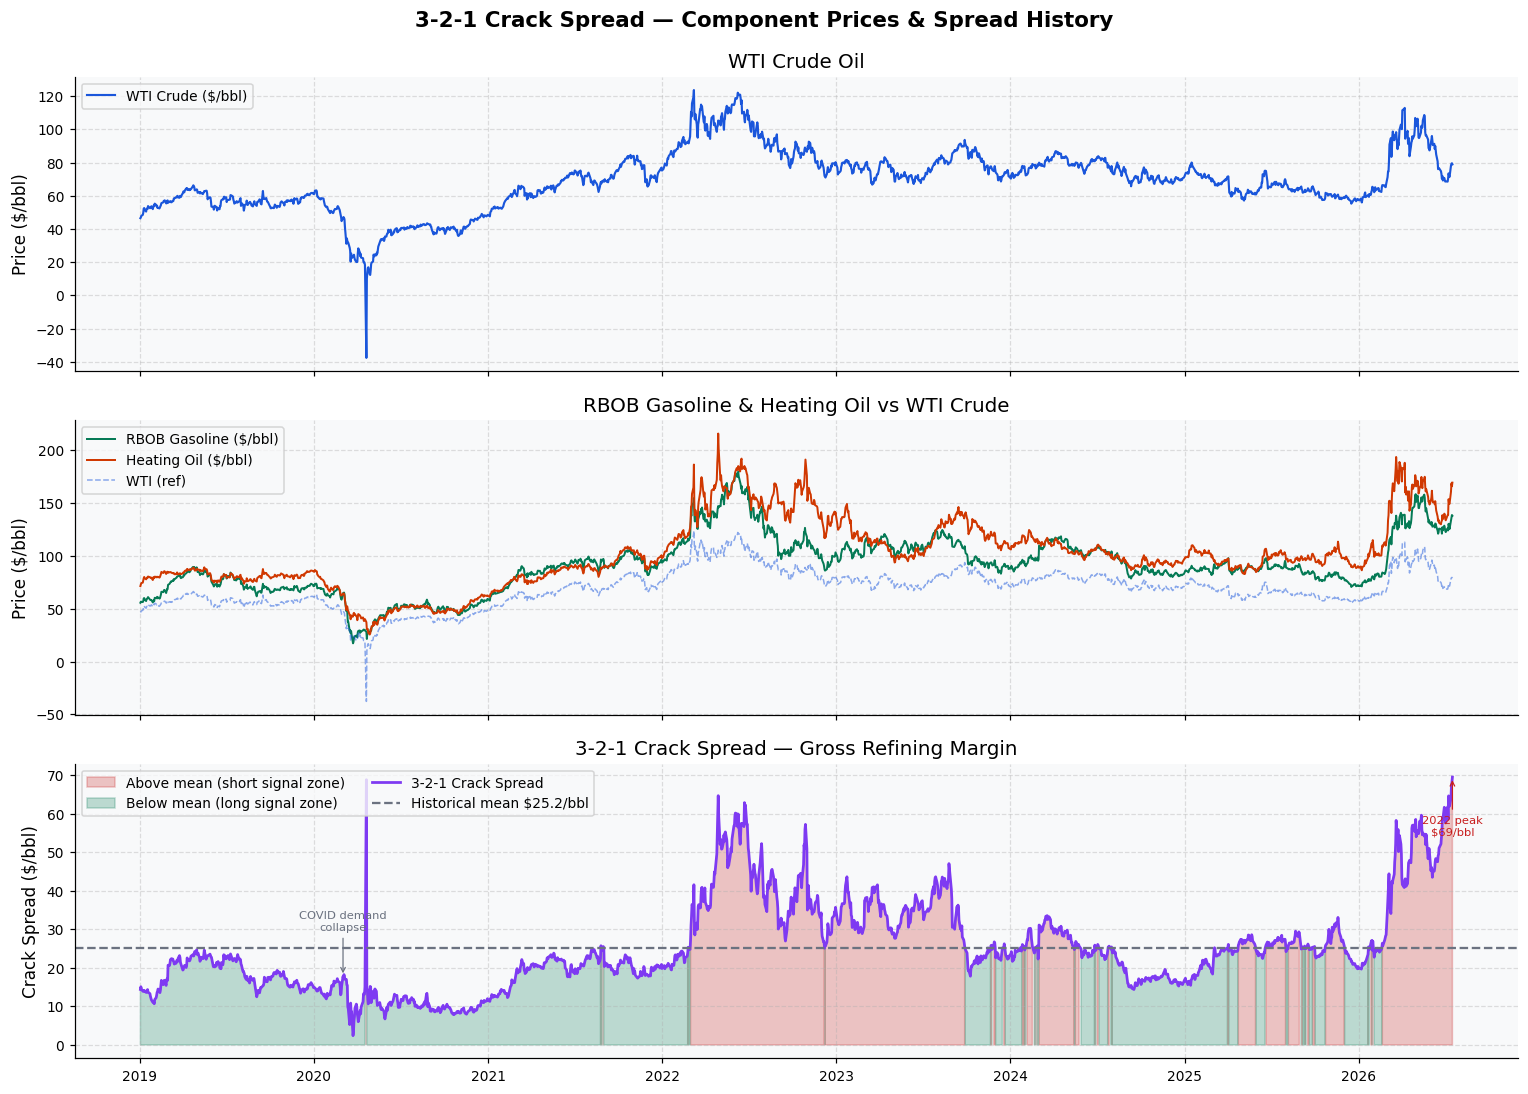

Figure 1 saved.


In [ ]:
# @title
# ── Figure 1: Component prices and crack spread history ───────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('3-2-1 Crack Spread — Component Prices & Spread History',
             fontsize=14, fontweight='bold', y=0.99)

# Panel A: WTI crude
ax = axes[0]
ax.plot(prices.index, prices['WTI'], color=C['crude'], lw=1.4, label='WTI Crude ($/bbl)')
ax.set_ylabel('Price ($/bbl)')
ax.set_title('WTI Crude Oil')
ax.legend(loc='upper left')

# Panel B: Refined products (in $/bbl for comparison)
ax = axes[1]
ax.plot(prices.index, prices['RBOB_bbl'], color=C['gas'],  lw=1.3, label='RBOB Gasoline ($/bbl)')
ax.plot(prices.index, prices['HO_bbl'],   color=C['heat'], lw=1.3, label='Heating Oil ($/bbl)')
ax.plot(prices.index, prices['WTI'],      color=C['crude'],lw=1.0, ls='--', alpha=0.5, label='WTI (ref)')
ax.set_ylabel('Price ($/bbl)')
ax.set_title('RBOB Gasoline & Heating Oil vs WTI Crude')
ax.legend(loc='upper left')

# Panel C: 3-2-1 crack spread
ax = axes[2]
ax.fill_between(prices.index, prices['Crack321'],
                where=prices['Crack321'] > prices['Crack321'].mean(),
                alpha=0.25, color=C['short'], label='Above mean (short signal zone)')
ax.fill_between(prices.index, prices['Crack321'],
                where=prices['Crack321'] < prices['Crack321'].mean(),
                alpha=0.25, color=C['long'], label='Below mean (long signal zone)')
ax.plot(prices.index, prices['Crack321'], color=C['spread'], lw=1.8, label='3-2-1 Crack Spread')
ax.axhline(prices['Crack321'].mean(), color=C['neutral'], lw=1.5, ls='--',
           label=f'Historical mean ${prices["Crack321"].mean():.1f}/bbl')
ax.set_ylabel('Crack Spread ($/bbl)')
ax.set_title('3-2-1 Crack Spread — Gross Refining Margin')
ax.legend(loc='upper left', ncol=2)

# Annotate key events
covid_idx = prices.index[prices.index >= '2020-03-01'][0]
peak_idx  = prices['Crack321'].idxmax()
ax.annotate('COVID demand\ncollapse', xy=(covid_idx, prices.loc[covid_idx, 'Crack321']),
            xytext=(covid_idx, prices.loc[covid_idx, 'Crack321'] + 12),
            fontsize=7.5, ha='center', color=C['neutral'],
            arrowprops=dict(arrowstyle='->', color=C['neutral'], lw=0.8))
ax.annotate(f'2022 peak\n${prices["Crack321"].max():.0f}/bbl',
            xy=(peak_idx, prices['Crack321'].max()),
            xytext=(peak_idx, prices['Crack321'].max() - 15),
            fontsize=7.5, ha='center', color=C['short'],
            arrowprops=dict(arrowstyle='->', color=C['short'], lw=0.8))

plt.tight_layout()
plt.savefig('01_crack_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## Section 4: Exploratory Analysis — Seasonality, Distribution & Mean-Reversion

Before building a trading strategy, we need to understand three things:

1. **Seasonality**: Does the crack spread follow predictable annual patterns? (It should — summer driving season, winter heating demand)
2. **Stationarity**: Is the spread stationary (mean-reverting) or does it have a unit root (random walk)? We test this with the **Augmented Dickey-Fuller test**.
3. **Autocorrelation**: At what lags does the spread exhibit serial correlation? This tells us the speed of mean-reversion and appropriate signal lookback windows.

### Augmented Dickey-Fuller Test
The ADF test has the null hypothesis that the series has a **unit root** (i.e., is a random walk — NOT mean-reverting).
- **p < 0.05**: Reject H₀ → series is stationary → **mean-reversion confirmed**
- **p > 0.05**: Fail to reject H₀ → series may be a random walk → mean-reversion strategy is risky

In [ ]:
# @title
import warnings
from statsmodels.tsa.stattools import adfuller
# The adfuller function in newer versions of statsmodels does not accept maxlags.
# autolag='AIC' can automatically determine the number of lags.
warnings.filterwarnings('ignore', category=FutureWarning)
# ── Augmented Dickey-Fuller Test ───────────────────────────────────────────────
spread_clean = prices['Crack321'].dropna()

adf_result = adfuller(spread_clean, autolag='AIC')

print('── Augmented Dickey-Fuller Test — 3-2-1 Crack Spread ────────────')
print(f'  H₀: Series has a unit root (random walk — NOT mean-reverting)')
print(f'  H₁: Series is stationary (mean-reverting)')
print(f'  ADF statistic : {adf_result[0]:.4f}')
print(f'  p-value       : {adf_result[1]:.6f}')
print(f'  Lags used     : {adf_result[2]}')
print(f'  Critical values:')
for pct, val in adf_result[4].items():
    marker = ' <-- test stat is more negative' if adf_result[0] < val else ''
    print(f'    {pct}: {val:.4f}{marker}')
print()
if adf_result[1] < 0.05:
    print('  RESULT: Reject H₀ at 5% significance.')
    print('  The crack spread is STATIONARY — mean-reversion strategy is justified.')
elif adf_result[1] >= 0.05:
    print('  RESULT: Cannot reject H₀. Series may not be stationary.')
    print('  Consider using first differences or a rolling z-score approach.')

# ── Half-life of mean reversion ────────────────────────────────────────────────
# Estimate via OLS regression: delta(X_t) = alpha + beta * X_{t-1} + epsilon
# Half-life = -ln(2) / beta
spread_lag  = spread_clean.shift(1).dropna()
spread_diff = spread_clean.diff().dropna()
idx = spread_lag.index.intersection(spread_diff.index)

ols = OLS(spread_diff.loc[idx], add_constant(spread_lag.loc[idx])).fit()
beta     = ols.params.iloc[1]
half_life = -np.log(2) / beta if beta < 0 else np.nan

print(f'\n── Mean-Reversion Speed ─────────────────────────────────────────')
print(f'  OLS beta (mean-reversion speed): {beta:.6f}')
print(f'  Half-life of mean reversion    : {half_life:.1f} trading days')
print(f'  (~{half_life/5:.1f} trading weeks)')
print(f'\n  Interpretation: On average, a deviation from the mean is half')
print(f'  corrected in {half_life:.0f} trading days. This suggests using a')
print(f'  {int(half_life*2)}-{int(half_life*3)}-day lookback window for signal generation.')


── Augmented Dickey-Fuller Test — 3-2-1 Crack Spread ────────────
  H₀: Series has a unit root (random walk — NOT mean-reverting)
  H₁: Series is stationary (mean-reverting)
  ADF statistic : -1.7580
  p-value       : 0.401501
  Lags used     : 3
  Critical values:
    1%: -3.4338
    5%: -2.8631
    10%: -2.5676

  RESULT: Cannot reject H₀. Series may not be stationary.
  Consider using first differences or a rolling z-score approach.

── Mean-Reversion Speed ─────────────────────────────────────────
  OLS beta (mean-reversion speed): -0.015700
  Half-life of mean reversion    : 44.1 trading days
  (~8.8 trading weeks)

  Interpretation: On average, a deviation from the mean is half
  corrected in 44 trading days. This suggests using a
  88-132-day lookback window for signal generation.


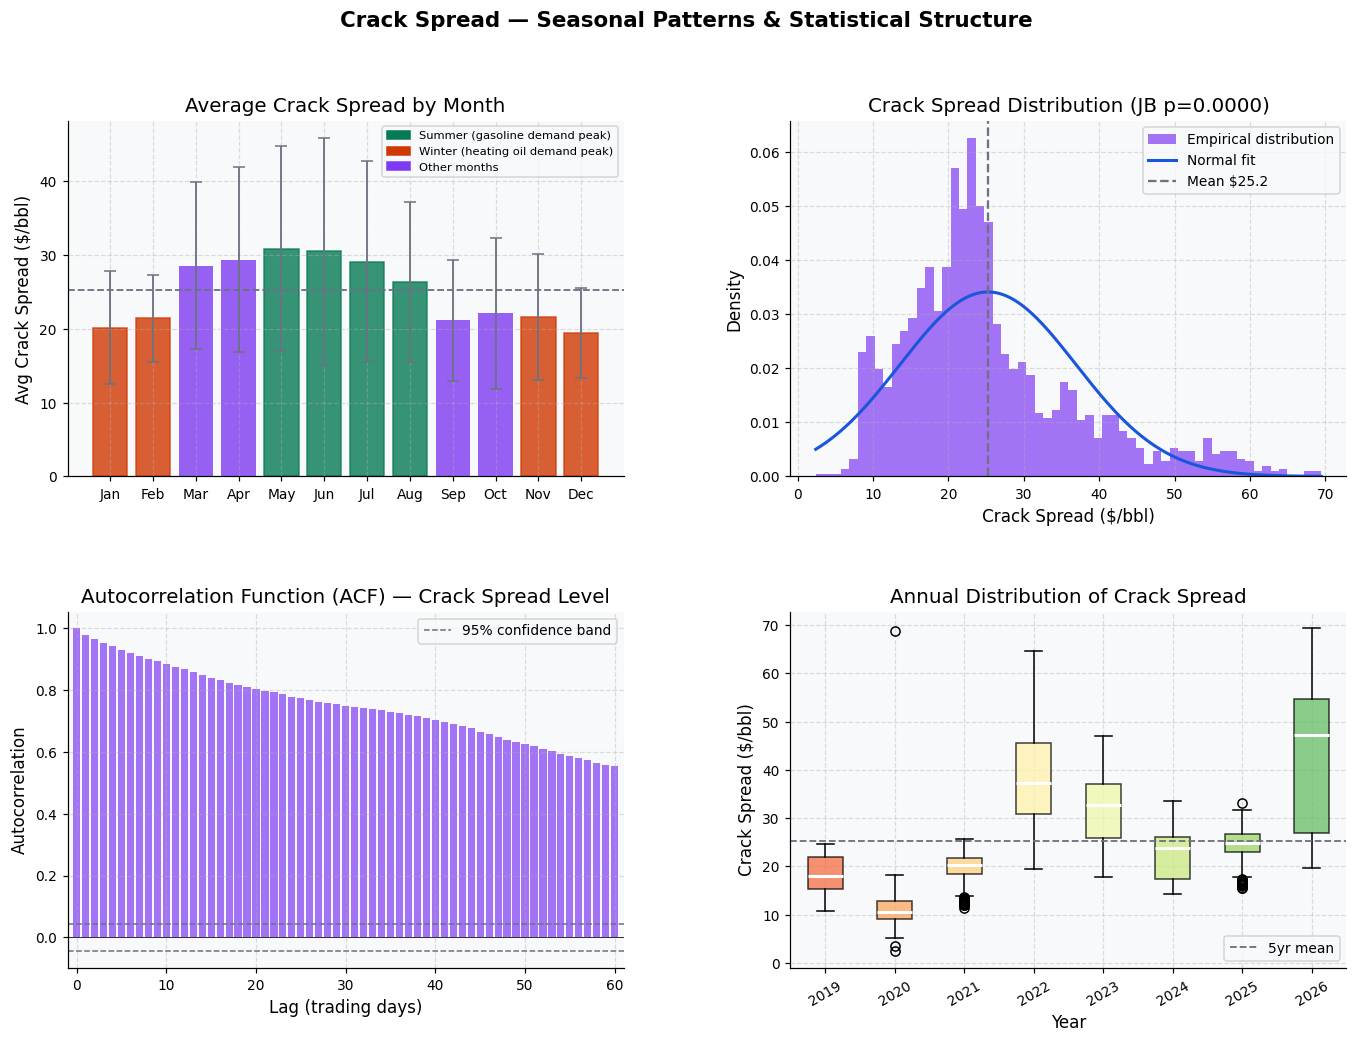

Figure 2 saved.

Key seasonal observations:
  Highest avg months : [5, 6, 4]
  Lowest avg months  : [12, 1, 9]


In [ ]:
# @title
# ── Seasonal Analysis ─────────────────────────────────────────────────────────
prices['Month'] = prices.index.month
prices['Year']  = prices.index.year
prices['Week']  = prices.index.isocalendar().week.astype(int)

# Average crack spread by month
monthly_avg = prices.groupby('Month')['Crack321'].agg(['mean','std','median'])
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── ACF / PACF Analysis ───────────────────────────────────────────────────────
acf_vals  = acf(spread_clean,  nlags=60, fft=True)
pacf_vals = pacf(spread_clean, nlags=30)

# ── Figure 2: Seasonality and autocorrelation ─────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Crack Spread — Seasonal Patterns & Statistical Structure',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# A: Monthly seasonality
ax = fig.add_subplot(gs[0, 0])
bars = ax.bar(month_names, monthly_avg['mean'], color=C['spread'], alpha=0.8)
ax.errorbar(month_names, monthly_avg['mean'], yerr=monthly_avg['std'],
            fmt='none', color=C['neutral'], capsize=4, lw=1.2)
ax.axhline(spread_clean.mean(), color=C['neutral'], lw=1.2, ls='--',
           label=f'Overall mean ${spread_clean.mean():.1f}')
# Color bars by season
summer_months = [5,6,7,8]  # May-Aug: gasoline demand peak
winter_months = [11,12,1,2]  # Nov-Feb: heating oil demand peak
for i, (bar, m) in enumerate(zip(bars, range(1,13))):
    if m in summer_months:
        bar.set_color(C['gas'])
    elif m in winter_months:
        bar.set_color(C['heat'])
ax.set_title('Average Crack Spread by Month')
ax.set_ylabel('Avg Crack Spread ($/bbl)')
ax.legend(fontsize=8)
from matplotlib.patches import Patch
leg_els = [Patch(color=C['gas'],  label='Summer (gasoline demand peak)'),
           Patch(color=C['heat'], label='Winter (heating oil demand peak)'),
           Patch(color=C['spread'],label='Other months')]
ax.legend(handles=leg_els, fontsize=7.5)

# B: Distribution of crack spread
ax = fig.add_subplot(gs[0, 1])
ax.hist(spread_clean, bins=60, color=C['spread'], alpha=0.7,
        density=True, label='Empirical distribution')
x_range = np.linspace(spread_clean.min(), spread_clean.max(), 200)
ax.plot(x_range, norm.pdf(x_range, spread_clean.mean(), spread_clean.std()),
        color=C['crude'], lw=2, label='Normal fit')
ax.axvline(spread_clean.mean(), color=C['neutral'], lw=1.5, ls='--',
           label=f'Mean ${spread_clean.mean():.1f}')
jb_stat, jb_p = jarque_bera(spread_clean)
ax.set_title(f'Crack Spread Distribution (JB p={jb_p:.4f})')
ax.set_xlabel('Crack Spread ($/bbl)')
ax.set_ylabel('Density')
ax.legend()

# C: ACF
ax = fig.add_subplot(gs[1, 0])
conf_int = 1.96 / np.sqrt(len(spread_clean))
lags_plot = np.arange(len(acf_vals))
ax.bar(lags_plot, acf_vals, color=C['spread'], alpha=0.7, width=0.8)
ax.axhline(conf_int,  color=C['neutral'], lw=1, ls='--', label='95% confidence band')
ax.axhline(-conf_int, color=C['neutral'], lw=1, ls='--')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Autocorrelation Function (ACF) — Crack Spread Level')
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel('Autocorrelation')
ax.legend()
ax.set_xlim(-1, 61)

# D: Annual spread evolution (box plots)
ax = fig.add_subplot(gs[1, 1])
years = sorted(prices['Year'].unique())
year_data = [prices.loc[prices['Year']==y, 'Crack321'].dropna().values for y in years]
bp = ax.boxplot(year_data, labels=years, patch_artist=True, notch=False,
                medianprops={'color':'white','lw':2})
colors_box = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(years)))
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax.axhline(spread_clean.mean(), color=C['neutral'], lw=1.2, ls='--',
           label=f'5yr mean')
ax.set_title('Annual Distribution of Crack Spread')
ax.set_xlabel('Year')
ax.set_ylabel('Crack Spread ($/bbl)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

plt.savefig('02_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')
print(f'\nKey seasonal observations:')
print(f'  Highest avg months : {monthly_avg["mean"].nlargest(3).index.tolist()}')
print(f'  Lowest avg months  : {monthly_avg["mean"].nsmallest(3).index.tolist()}')

---
## Section 5: Ornstein-Uhlenbeck Mean-Reversion Model

The crack spread is modeled as an **Ornstein-Uhlenbeck (OU) process** — the continuous-time analog of an AR(1) process, and the standard model for mean-reverting commodity spreads in academic literature (Schwartz, 1997).

### The OU SDE

$$dX_t = \kappa(\mu - X_t)\, dt + \sigma\, dW_t$$

where:
- $\kappa$ = **mean-reversion speed** (higher = reverts faster)
- $\mu$ = **long-run equilibrium level** (where the spread gravitates)
- $\sigma$ = **volatility** of the spread
- $W_t$ = standard Brownian motion

### Discrete-Time Equivalent (AR(1))

In daily data, the OU process becomes:

$$X_t = a + b X_{t-1} + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, \sigma_\epsilon^2)$$

We recover the OU parameters:
- $\kappa = -\ln(b) / \Delta t$
- $\mu = a / (1-b)$  
- $\sigma = \sigma_\epsilon \sqrt{-2\ln(b) / (\Delta t (1-b^2))}$

### Seasonal OU Model

We extend the basic OU model with a **deterministic seasonal component** $s(t)$:

$$dX_t = \kappa(\mu + s(t) - X_t)\, dt + \sigma\, dW_t$$

where $s(t) = A_1 \sin(2\pi t / 252) + B_1 \cos(2\pi t / 252)$ captures the annual demand cycle.

In [ ]:
# @title
# ── Ornstein-Uhlenbeck Parameter Estimation ───────────────────────────────────

def fit_ou_ols(series):
    """
    Fit Ornstein-Uhlenbeck parameters via OLS on the discrete AR(1) representation.
    X_t = a + b*X_{t-1} + epsilon_t
    """
    x_lag  = series.shift(1).dropna()
    x_curr = series.loc[x_lag.index]

    model = OLS(x_curr, add_constant(x_lag)).fit()
    a, b  = model.params
    sigma_eps = np.std(model.resid)

    dt = 1 / 252  # Daily intervals (fraction of year)

    kappa    = -np.log(b) / dt if b > 0 else np.nan
    mu       = a / (1 - b)    if abs(1-b) > 1e-10 else np.nan
    sigma_ou = sigma_eps * np.sqrt(-2 * np.log(b) / (dt * (1 - b**2))) \
               if b > 0 and b < 1 else sigma_eps * np.sqrt(252)
    half_life = np.log(2) / kappa * 252 if kappa > 0 else np.nan

    return {
        'kappa':     kappa,
        'mu':        mu,
        'sigma':     sigma_ou,
        'half_life': half_life,
        'b':         b,
        'a':         a,
        'sigma_eps': sigma_eps,
        'r_squared': model.rsquared,
        'residuals': model.resid,
    }

# ── Fit on full sample ─────────────────────────────────────────────────────────
ou_params = fit_ou_ols(spread_clean)

print('── Ornstein-Uhlenbeck Model Parameters ─────────────────────────────')
print(f'  Long-run mean (mu)     : ${ou_params["mu"]:.4f}/bbl')
print(f'  Mean-reversion speed   : {ou_params["kappa"]:.4f} per year')
print(f'  Half-life              : {ou_params["half_life"]:.1f} trading days')
print(f'  Volatility (sigma)     : ${ou_params["sigma"]:.4f}/bbl per year')
print(f'  AR(1) coefficient (b)  : {ou_params["b"]:.6f}')
print(f'  Daily residual vol     : ${ou_params["sigma_eps"]:.4f}/bbl')
print(f'  R-squared              : {ou_params["r_squared"]:.6f}')
print()
print(f'  Implication: A spread deviation is half-corrected in')
print(f'  {ou_params["half_life"]:.0f} trading days (~{ou_params["half_life"]/5:.1f} weeks).')
print(f'  Signal lookback should be at least {2*ou_params["half_life"]:.0f} days.')

# ── Seasonal Component via Fourier Terms ──────────────────────────────────────
t = np.arange(len(spread_clean))
# Annual period = 252 trading days
spread_df_ou = pd.DataFrame({'spread': spread_clean.values,
                              'sin1': np.sin(2*np.pi*t/252),
                              'cos1': np.cos(2*np.pi*t/252),
                              'sin2': np.sin(4*np.pi*t/252),
                              'cos2': np.cos(4*np.pi*t/252)},
                             index=spread_clean.index)

seasonal_model = OLS(spread_df_ou['spread'],
                     add_constant(spread_df_ou[['sin1','cos1','sin2','cos2']])).fit()
prices.loc[spread_clean.index, 'Seasonal'] = seasonal_model.fittedvalues
prices.loc[spread_clean.index, 'Deseasonalized'] = (
    spread_clean.values - seasonal_model.fittedvalues
)

print(f'\n── Seasonal Model ────────────────────────────────────────────────────')
print(f'  Seasonal model R²      : {seasonal_model.rsquared:.4f}')
print(f'  Seasonal amplitude     : ${seasonal_model.fittedvalues.std():.2f}/bbl')
print(f'  Deseasonalized std     : ${prices["Deseasonalized"].std():.2f}/bbl')

── Ornstein-Uhlenbeck Model Parameters ─────────────────────────────
  Long-run mean (mu)     : $27.0772/bbl
  Mean-reversion speed   : 3.9879 per year
  Half-life              : 43.8 trading days
  Volatility (sigma)     : $36.4328/bbl per year
  AR(1) coefficient (b)  : 0.984300
  Daily residual vol     : $2.2770/bbl
  R-squared              : 0.961955

  Implication: A spread deviation is half-corrected in
  44 trading days (~8.8 weeks).
  Signal lookback should be at least 88 days.

── Seasonal Model ────────────────────────────────────────────────────
  Seasonal model R²      : 0.1257
  Seasonal amplitude     : $4.14/bbl
  Deseasonalized std     : $10.92/bbl


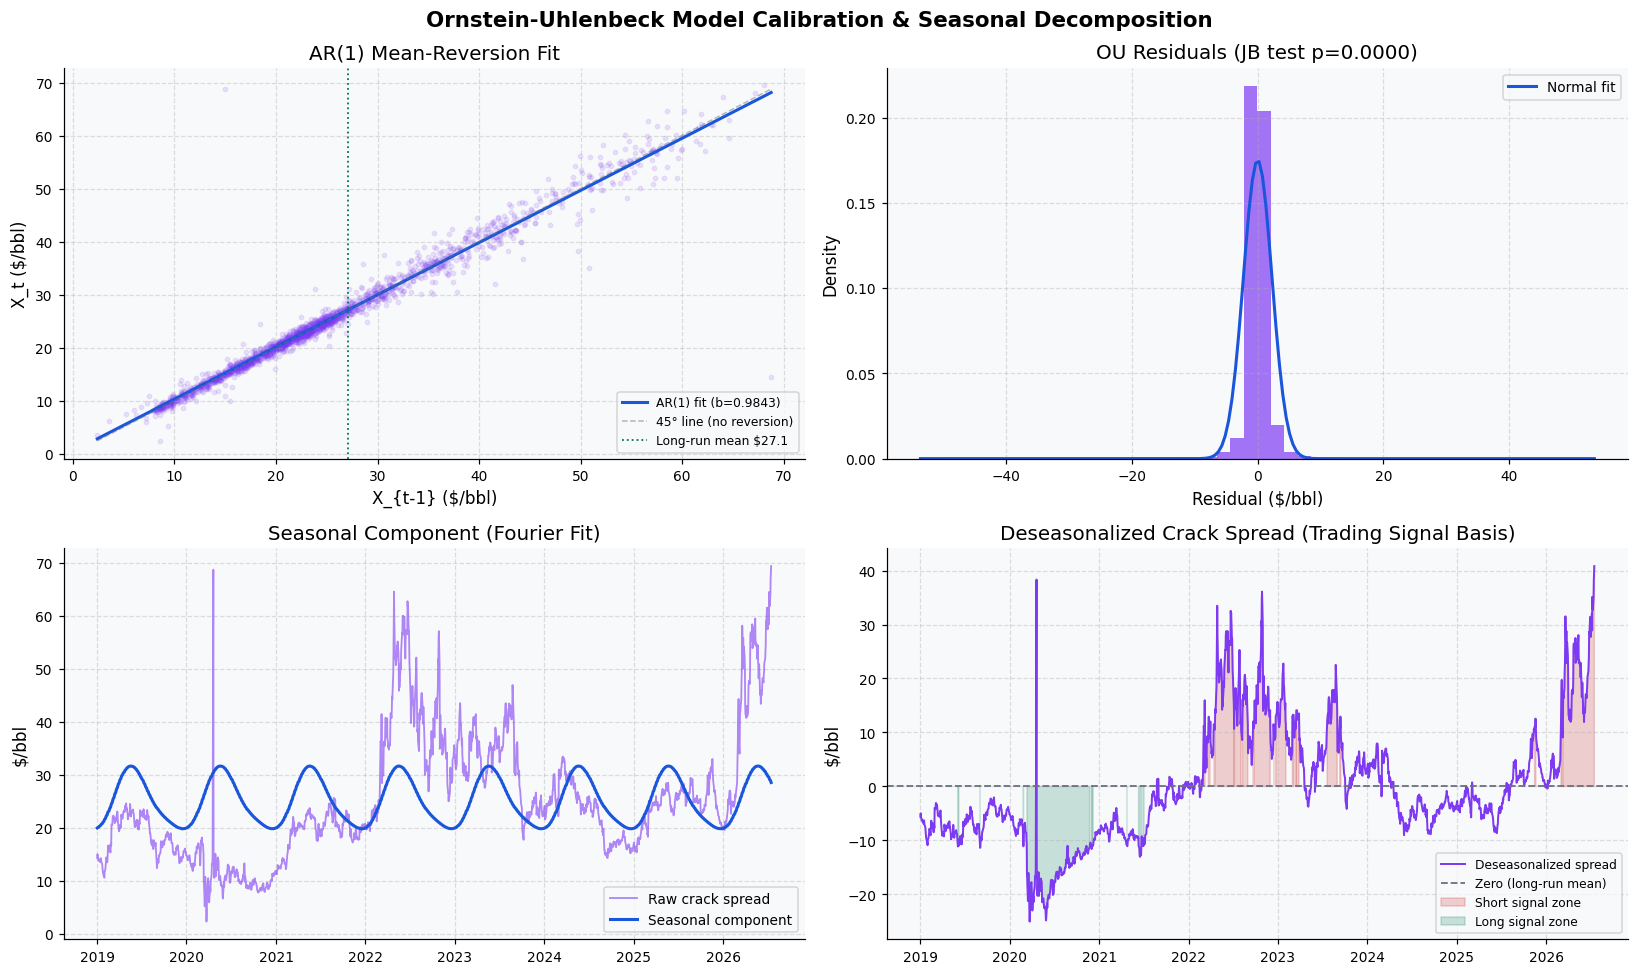

Figure 3 saved.


In [ ]:
# @title
# ── Figure 3: OU model fit and seasonal decomposition ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Ornstein-Uhlenbeck Model Calibration & Seasonal Decomposition',
             fontsize=14, fontweight='bold')

# A: OU mean-reversion fit
ax = axes[0, 0]
x_lag_plot = spread_clean.shift(1).dropna()
x_curr_plot= spread_clean.loc[x_lag_plot.index]
ax.scatter(x_lag_plot, x_curr_plot, alpha=0.12, s=8, color=C['spread'])
x_line = np.linspace(x_lag_plot.min(), x_lag_plot.max(), 100)
ax.plot(x_line, ou_params['a'] + ou_params['b'] * x_line,
        color=C['crude'], lw=2, label=f"AR(1) fit (b={ou_params['b']:.4f})")
ax.plot(x_line, x_line, color=C['neutral'], lw=1, ls='--', alpha=0.5, label='45° line (no reversion)')
ax.axvline(ou_params['mu'], color=C['long'], lw=1.2, ls=':',
           label=f'Long-run mean ${ou_params["mu"]:.1f}')
ax.set_xlabel('X_{t-1} ($/bbl)')
ax.set_ylabel('X_t ($/bbl)')
ax.set_title('AR(1) Mean-Reversion Fit')
ax.legend(fontsize=8)

# B: Residuals distribution (should be ~normal)
ax = axes[0, 1]
resid = ou_params['residuals']
ax.hist(resid, bins=50, color=C['spread'], alpha=0.7, density=True)
x_r = np.linspace(resid.min(), resid.max(), 200)
ax.plot(x_r, norm.pdf(x_r, resid.mean(), resid.std()),
        color=C['crude'], lw=2, label='Normal fit')
jb_s, jb_p2 = jarque_bera(resid)
ax.set_title(f'OU Residuals (JB test p={jb_p2:.4f})')
ax.set_xlabel('Residual ($/bbl)')
ax.set_ylabel('Density')
ax.legend()

# C: Seasonal component
ax = axes[1, 0]
ax.plot(prices.index, prices['Crack321'], color=C['spread'],
        lw=1.2, alpha=0.6, label='Raw crack spread')
ax.plot(prices.index, prices['Seasonal'], color=C['crude'],
        lw=2, label='Seasonal component')
ax.set_ylabel('$/bbl')
ax.set_title('Seasonal Component (Fourier Fit)')
ax.legend()

# D: Deseasonalized spread
ax = axes[1, 1]
deseas = prices['Deseasonalized'].dropna()
ax.plot(deseas.index, deseas, color=C['spread'], lw=1.3,
        label='Deseasonalized spread')
ax.axhline(0, color=C['neutral'], lw=1.2, ls='--', label='Zero (long-run mean)')
ax.fill_between(deseas.index, deseas, 0,
                where=deseas > deseas.std(), alpha=0.2, color=C['short'],
                label='Short signal zone')
ax.fill_between(deseas.index, deseas, 0,
                where=deseas < -deseas.std(), alpha=0.2, color=C['long'],
                label='Long signal zone')
ax.set_ylabel('$/bbl')
ax.set_title('Deseasonalized Crack Spread (Trading Signal Basis)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('03_ou_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## Section 6: Trading Signal Generation

### Z-Score Signal

The core signal is a **rolling z-score** of the deseasonalized crack spread:

$$z_t = \frac{X_t - \mu_{t,n}}{\sigma_{t,n}}$$

where $\mu_{t,n}$ and $\sigma_{t,n}$ are the **rolling mean and standard deviation** over the past $n$ trading days. This makes the signal adaptive — it adjusts to regime changes in the level of the spread.

### Trading Rules

| Signal | Condition | Trade | Rationale |
|--------|-----------|-------|-----------|
| **Long crack** | $z_t < -z_{entry}$ | Buy spread | Spread too low; expect widening |
| **Exit long** | $z_t > -z_{exit}$ | Close | Spread reverted toward mean |
| **Short crack** | $z_t > +z_{entry}$ | Sell spread | Spread too high; expect narrowing |
| **Exit short** | $z_t < +z_{exit}$ | Close | Spread reverted toward mean |

**Typical parameters:** entry threshold $z_{entry} = 1.5$, exit threshold $z_{exit} = 0.5$.

### Position Implementation
Going **long the 3-2-1 crack spread** means:
- Long $\frac{2}{3}$ of 1 RBOB gasoline futures contract
- Long $\frac{1}{3}$ of 1 Heating Oil futures contract
- Short 1 WTI crude oil futures contract

Going **short** is the reverse.

In [ ]:
# @title
# ── Signal Parameters ─────────────────────────────────────────────────────────
LOOKBACK    = 60     # Rolling window for z-score (trading days)
Z_ENTRY     = 1.5   # Z-score threshold to enter a trade
Z_EXIT      = 0.5   # Z-score threshold to exit a trade
Z_STOP      = 3.0   # Stop-loss: exit if z-score exceeds this (trend, not reversion)

# ── Compute rolling z-score on deseasonalized spread ─────────────────────────
deseas_series = prices['Deseasonalized'].dropna()

prices['RollingMean'] = deseas_series.rolling(LOOKBACK).mean()
prices['RollingStd']  = deseas_series.rolling(LOOKBACK).std()
prices['ZScore'] = (
    (deseas_series - prices['RollingMean']) / prices['RollingStd']
)

# ── Also compute z-score on raw spread (for comparison) ───────────────────────
prices['ZScore_Raw'] = (
    (prices['Crack321'] - prices['Crack321'].rolling(LOOKBACK).mean())
    / prices['Crack321'].rolling(LOOKBACK).std()
)

# ── Generate raw signals (before position state machine) ──────────────────────
prices['Signal_Raw'] = 0
prices.loc[prices['ZScore'] < -Z_ENTRY, 'Signal_Raw'] =  1   # Long crack
prices.loc[prices['ZScore'] >  Z_ENTRY, 'Signal_Raw'] = -1   # Short crack

# ── Position State Machine (handles entry, exit, stops) ───────────────────────
# A position persists until the exit/stop condition is met
positions = []
pos = 0  # current position: 0=flat, 1=long, -1=short

for idx, row in prices.iterrows():
    z = row['ZScore']
    if np.isnan(z):
        positions.append(0)
        continue

    if pos == 0:  # Flat — look for entry
        if z < -Z_ENTRY:
            pos = 1    # Enter long
        elif z > Z_ENTRY:
            pos = -1   # Enter short

    elif pos == 1:  # Long — look for exit or stop
        if z > -Z_EXIT:   # Mean reverted — exit
            pos = 0
        elif z > Z_STOP:  # Stop-loss (became very wide — now trending short)
            pos = 0

    elif pos == -1:  # Short — look for exit or stop
        if z < Z_EXIT:    # Mean reverted — exit
            pos = 0
        elif z < -Z_STOP: # Stop-loss (became very narrow — now trending long)
            pos = 0

    positions.append(pos)

prices['Position'] = positions

# ── Signal statistics ─────────────────────────────────────────────────────────
n_long   = (prices['Position'] == 1).sum()
n_short  = (prices['Position'] ==-1).sum()
n_flat   = (prices['Position'] == 0).sum()
n_total  = len(prices.dropna(subset=['ZScore']))

print(f'── Signal Statistics (lookback={LOOKBACK}d, entry={Z_ENTRY}σ, exit={Z_EXIT}σ) ───')
print(f'  Days in market  : {n_long + n_short} ({(n_long+n_short)/n_total*100:.1f}%)')
print(f'  Days long crack : {n_long} ({n_long/n_total*100:.1f}%)')
print(f'  Days short crack: {n_short} ({n_short/n_total*100:.1f}%)')
print(f'  Days flat       : {n_flat} ({n_flat/n_total*100:.1f}%)')

# Count trades (position changes)
pos_series = prices['Position']
entries = (pos_series != pos_series.shift(1)) & (pos_series != 0)
print(f'  Total trades    : {entries.sum()}')

── Signal Statistics (lookback=60d, entry=1.5σ, exit=0.5σ) ───
  Days in market  : 890 (48.4%)
  Days long crack : 338 (18.4%)
  Days short crack: 552 (30.0%)
  Days flat       : 1006 (54.8%)
  Total trades    : 50


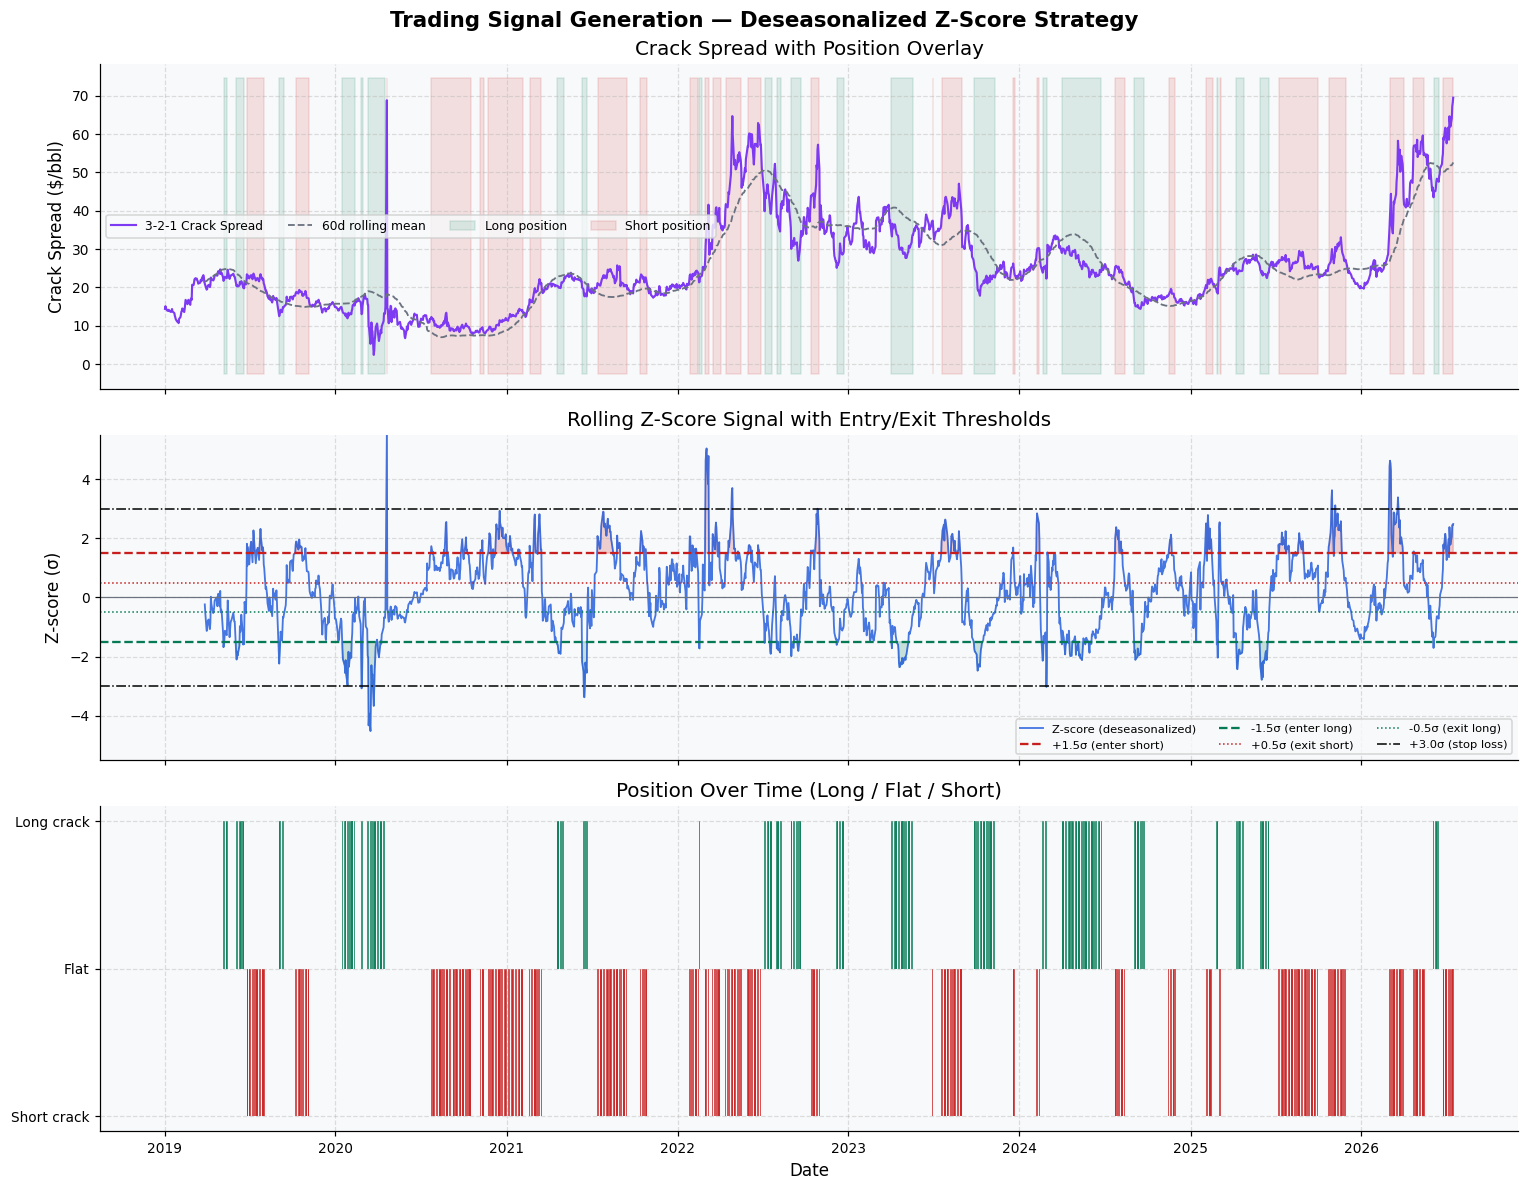

Figure 4 saved.


In [ ]:
# @title
# ── Figure 4: Signal visualization ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Trading Signal Generation — Deseasonalized Z-Score Strategy',
             fontsize=14, fontweight='bold')

# A: Crack spread with position overlay
ax = axes[0]
ax.plot(prices.index, prices['Crack321'], color=C['spread'], lw=1.4,
        label='3-2-1 Crack Spread')
ax.plot(prices.index, prices['RollingMean'] + prices['Seasonal'],
        color=C['neutral'], lw=1.2, ls='--', label=f'{LOOKBACK}d rolling mean')
# Shade positions
ax.fill_between(prices.index, prices['Crack321'].min() - 5, prices['Crack321'].max() + 5,
                where=prices['Position'] == 1, alpha=0.12, color=C['long'],
                label='Long position')
ax.fill_between(prices.index, prices['Crack321'].min() - 5, prices['Crack321'].max() + 5,
                where=prices['Position'] ==-1, alpha=0.12, color=C['short'],
                label='Short position')
ax.set_ylabel('Crack Spread ($/bbl)')
ax.set_title('Crack Spread with Position Overlay')
ax.legend(fontsize=8, ncol=4)

# B: Z-score with thresholds
ax = axes[1]
ax.plot(prices.index, prices['ZScore'], color=C['crude'], lw=1.2,
        alpha=0.8, label='Z-score (deseasonalized)')
ax.axhline(0, color=C['neutral'], lw=0.8)
ax.axhline( Z_ENTRY, color=C['short'], lw=1.5, ls='--', label=f'+{Z_ENTRY}σ (enter short)')
ax.axhline(-Z_ENTRY, color=C['long'],  lw=1.5, ls='--', label=f'-{Z_ENTRY}σ (enter long)')
ax.axhline( Z_EXIT,  color=C['short'], lw=1.0, ls=':',  label=f'+{Z_EXIT}σ (exit short)')
ax.axhline(-Z_EXIT,  color=C['long'],  lw=1.0, ls=':',  label=f'-{Z_EXIT}σ (exit long)')
ax.axhline( Z_STOP,  color='black',   lw=1.0, ls='-.',  label=f'+{Z_STOP}σ (stop loss)')
ax.axhline(-Z_STOP,  color='black',   lw=1.0, ls='-.',  )
ax.fill_between(prices.index, prices['ZScore'], Z_ENTRY,
                where=prices['ZScore'] > Z_ENTRY, alpha=0.2, color=C['short'])
ax.fill_between(prices.index, prices['ZScore'], -Z_ENTRY,
                where=prices['ZScore'] < -Z_ENTRY, alpha=0.2, color=C['long'])
ax.set_ylabel('Z-score (σ)')
ax.set_title('Rolling Z-Score Signal with Entry/Exit Thresholds')
ax.legend(fontsize=7.5, ncol=3)
ax.set_ylim(-5.5, 5.5)

# C: Position over time
ax = axes[2]
colors_pos = prices['Position'].map({1: C['long'], -1: C['short'], 0: C['neutral']})
ax.bar(prices.index, prices['Position'],
       color=colors_pos.values, alpha=0.75, width=1.5)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Short crack', 'Flat', 'Long crack'])
ax.set_title('Position Over Time (Long / Flat / Short)')
ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig('04_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## Section 7: Backtest Engine

### P&L Calculation

The strategy trades the **3-2-1 crack spread** as a unit. Daily P&L when holding a position:

$$\text{PnL}_t = \text{Position}_{t-1} \times \Delta\text{Crack}_t \times \text{Notional}$$

where $\Delta\text{Crack}_t = \text{Crack}_t - \text{Crack}_{t-1}$ is the daily change in the spread.

### Transaction Costs

Each round-trip trade incurs costs from three legs:
- **WTI futures**: ~\$0.01/bbl commission + \$0.02/bbl bid-ask spread = \$0.03/bbl
- **RBOB gasoline**: ~\$0.001/gal × 42 = \$0.042/bbl per leg
- **Heating Oil**: ~\$0.001/gal × 42 = \$0.042/bbl per leg

Total round-trip cost: approximately **\$0.15-0.25/bbl** for the combined 3-2-1 structure. We use \$0.20/bbl as our cost assumption.

### Position Sizing

We use a **fixed notional** approach: each trade represents **10,000 barrels** of crude oil (equivalent to ~10 NYMEX WTI futures contracts of 1,000 bbl each). This is a realistic minimum institutional trade size.

In [ ]:
# @title
# ── Backtest Parameters ────────────────────────────────────────────────────────
BARRELS_PER_TRADE = 10_000     # Notional: 10 WTI futures contracts × 1,000 bbl
COST_PER_BBL      = 0.20       # Round-trip transaction cost ($/bbl)
INITIAL_CAPITAL   = 5_000_000  # $5M starting capital

# ── Compute daily P&L ─────────────────────────────────────────────────────────
bt = prices[['Crack321','Position','ZScore']].copy().dropna(subset=['Position'])

# Spread change (daily P&L driver)
bt['CrackChg'] = bt['Crack321'].diff()

# Gross P&L: position held yesterday × spread change today × notional
bt['GrossPnL'] = bt['Position'].shift(1) * bt['CrackChg'] * BARRELS_PER_TRADE

# Detect trade entries (position changes from 0 to non-0, or flips)
bt['TradeEntry'] = (
    (bt['Position'] != bt['Position'].shift(1)) &
    (bt['Position'] != 0)
).astype(int)

# Transaction cost applied on entry day
bt['TxCost'] = bt['TradeEntry'] * COST_PER_BBL * BARRELS_PER_TRADE

# Net P&L after costs
bt['NetPnL'] = bt['GrossPnL'] - bt['TxCost']
bt['NetPnL'] = bt['NetPnL'].fillna(0)

# Cumulative P&L and capital
bt['CumPnL']    = bt['NetPnL'].cumsum()
bt['Capital']   = INITIAL_CAPITAL + bt['CumPnL']
bt['CumReturn'] = bt['CumPnL'] / INITIAL_CAPITAL
bt['DailyRet']  = bt['NetPnL'] / INITIAL_CAPITAL

# ── Per-Trade Analysis ─────────────────────────────────────────────────────────
# Group trades by entry/exit points
bt['TradeID'] = 0
trade_id = 0
for i in range(1, len(bt)):
    if bt['TradeEntry'].iloc[i] == 1:
        trade_id += 1
    if bt['Position'].iloc[i] != 0:
        bt.iloc[i, bt.columns.get_loc('TradeID')] = trade_id

trade_pnl = bt[bt['TradeID'] > 0].groupby('TradeID')['NetPnL'].sum()

print(f'── Backtest Complete ─────────────────────────────────────────────')
print(f'  Period           : {bt.index[0].date()} to {bt.index[-1].date()}')
print(f'  Initial capital  : ${INITIAL_CAPITAL:,.0f}')
print(f'  Final capital    : ${bt["Capital"].iloc[-1]:,.0f}')
print(f'  Total P&L        : ${bt["CumPnL"].iloc[-1]:,.0f}')
print(f'  Total return     : {bt["CumReturn"].iloc[-1]:.1%}')
print(f'  Total trades     : {int(bt["TradeEntry"].sum())}')
print(f'  Total tx costs   : ${bt["TxCost"].sum():,.0f}')
print(f'  Cost drag        : ${bt["TxCost"].sum() / bt["TradeEntry"].sum():,.0f} per trade')

── Backtest Complete ─────────────────────────────────────────────
  Period           : 2019-01-02 to 2026-07-16
  Initial capital  : $5,000,000
  Final capital    : $6,324,606
  Total P&L        : $1,324,606
  Total return     : 26.5%
  Total trades     : 50
  Total tx costs   : $100,000
  Cost drag        : $2,000 per trade


---
## Section 8: Performance Analytics

We compute the full suite of institutional performance metrics used by hedge fund risk teams and investors:

| Metric | Formula | What It Measures |
|--------|---------|------------------|
| **Sharpe Ratio** | $(R_p - R_f) / \sigma_p$ | Risk-adjusted return per unit of total volatility |
| **Sortino Ratio** | $(R_p - R_f) / \sigma_{downside}$ | Risk-adjusted return per unit of downside volatility only |
| **Calmar Ratio** | $R_p^{annual} / |\text{MaxDD}|$ | Annual return per unit of maximum drawdown |
| **Max Drawdown** | $\max(\text{peak} - \text{trough})$ | Largest peak-to-trough capital loss |
| **Hit Rate** | Winning trades / Total trades | Fraction of trades that are profitable |
| **Profit Factor** | Gross profits / Gross losses | Total wins vs total losses |
| **Win/Loss Ratio** | Avg win / Avg loss | Average winning trade vs average losing trade |

In [ ]:
# @title
# ── Performance Metrics ────────────────────────────────────────────────────────
daily_ret = bt['DailyRet'].dropna()
RF_DAILY  = 0.05 / 252   # Risk-free rate (5% annual, daily)

# Annualization
ann_return = daily_ret.mean() * 252
ann_vol    = daily_ret.std()  * np.sqrt(252)

# Sharpe Ratio
excess_ret = daily_ret - RF_DAILY
sharpe     = excess_ret.mean() / daily_ret.std() * np.sqrt(252)

# Sortino Ratio (only downside deviation)
downside   = daily_ret[daily_ret < RF_DAILY] - RF_DAILY
sortino    = (excess_ret.mean() * 252) / (downside.std() * np.sqrt(252)) \
             if len(downside) > 0 else np.nan

# Maximum Drawdown
cum_capital = bt['Capital']
running_max = cum_capital.cummax()
drawdown    = (cum_capital - running_max) / running_max
max_dd      = drawdown.min()
max_dd_dur  = 0
in_dd, dd_dur = False, 0
for d in drawdown:
    if d < 0:
        dd_dur += 1
        max_dd_dur = max(max_dd_dur, dd_dur)
    else:
        dd_dur = 0

# Calmar Ratio
calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

# Trade-level statistics
winning_trades = trade_pnl[trade_pnl > 0]
losing_trades  = trade_pnl[trade_pnl <= 0]
hit_rate       = len(winning_trades) / len(trade_pnl) if len(trade_pnl) > 0 else 0
avg_win        = winning_trades.mean() if len(winning_trades) > 0 else 0
avg_loss       = losing_trades.mean()  if len(losing_trades) > 0  else 0
win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.nan
profit_factor  = (winning_trades.sum() / abs(losing_trades.sum())
                  if len(losing_trades) > 0 else np.nan)

# Value at Risk
var_95 = np.percentile(daily_ret, 5)
cvar_95 = daily_ret[daily_ret <= var_95].mean()

# ── Print performance report ───────────────────────────────────────────────────
print('=' * 62)
print('  STRATEGY PERFORMANCE REPORT')
print(f'  3-2-1 Crack Spread Mean-Reversion')
print(f'  {bt.index[0].date()} to {bt.index[-1].date()}')
print('=' * 62)
print(f'  RETURNS')
print(f'    Total P&L            : ${bt["CumPnL"].iloc[-1]:>12,.0f}')
print(f'    Total Return         : {bt["CumReturn"].iloc[-1]:>11.2%}')
print(f'    Annual Return        : {ann_return:>11.2%}')
print(f'    Annual Volatility    : {ann_vol:>11.2%}')
print(f'  RISK-ADJUSTED')
print(f'    Sharpe Ratio         : {sharpe:>11.4f}')
print(f'    Sortino Ratio        : {sortino:>11.4f}')
print(f'    Calmar Ratio         : {calmar:>11.4f}')
print(f'  DRAWDOWN')
print(f'    Max Drawdown         : {max_dd:>11.2%}')
print(f'    Longest DD (days)    : {max_dd_dur:>11d}')
print(f'  TRADE STATISTICS')
print(f'    Total Trades         : {len(trade_pnl):>11d}')
print(f'    Hit Rate             : {hit_rate:>11.1%}')
print(f'    Avg Winning Trade    : ${avg_win:>11,.0f}')
print(f'    Avg Losing Trade     : ${avg_loss:>11,.0f}')
print(f'    Win/Loss Ratio       : {win_loss_ratio:>11.2f}x')
print(f'    Profit Factor        : {profit_factor:>11.2f}x')
print(f'  TAIL RISK')
print(f'    Daily VaR 95%        : {var_95:>11.4%}')
print(f'    Daily CVaR 95%       : {cvar_95:>11.4%}')
print('=' * 62)

  STRATEGY PERFORMANCE REPORT
  3-2-1 Crack Spread Mean-Reversion
  2019-01-02 to 2026-07-16
  RETURNS
    Total P&L            : $   1,324,606
    Total Return         :      26.49%
    Annual Return        :       3.52%
    Annual Volatility    :       5.39%
  RISK-ADJUSTED
    Sharpe Ratio         :     -0.2745
    Sortino Ratio        :     -0.6207
    Calmar Ratio         :      0.8352
  DRAWDOWN
    Max Drawdown         :      -4.22%
    Longest DD (days)    :         400
  TRADE STATISTICS
    Total Trades         :          50
    Hit Rate             :       48.0%
    Avg Winning Trade    : $     19,892
    Avg Losing Trade     : $    -27,741
    Win/Loss Ratio       :        0.72x
    Profit Factor        :        0.66x
  TAIL RISK
    Daily VaR 95%        :    -0.2441%
    Daily CVaR 95%       :    -0.5266%


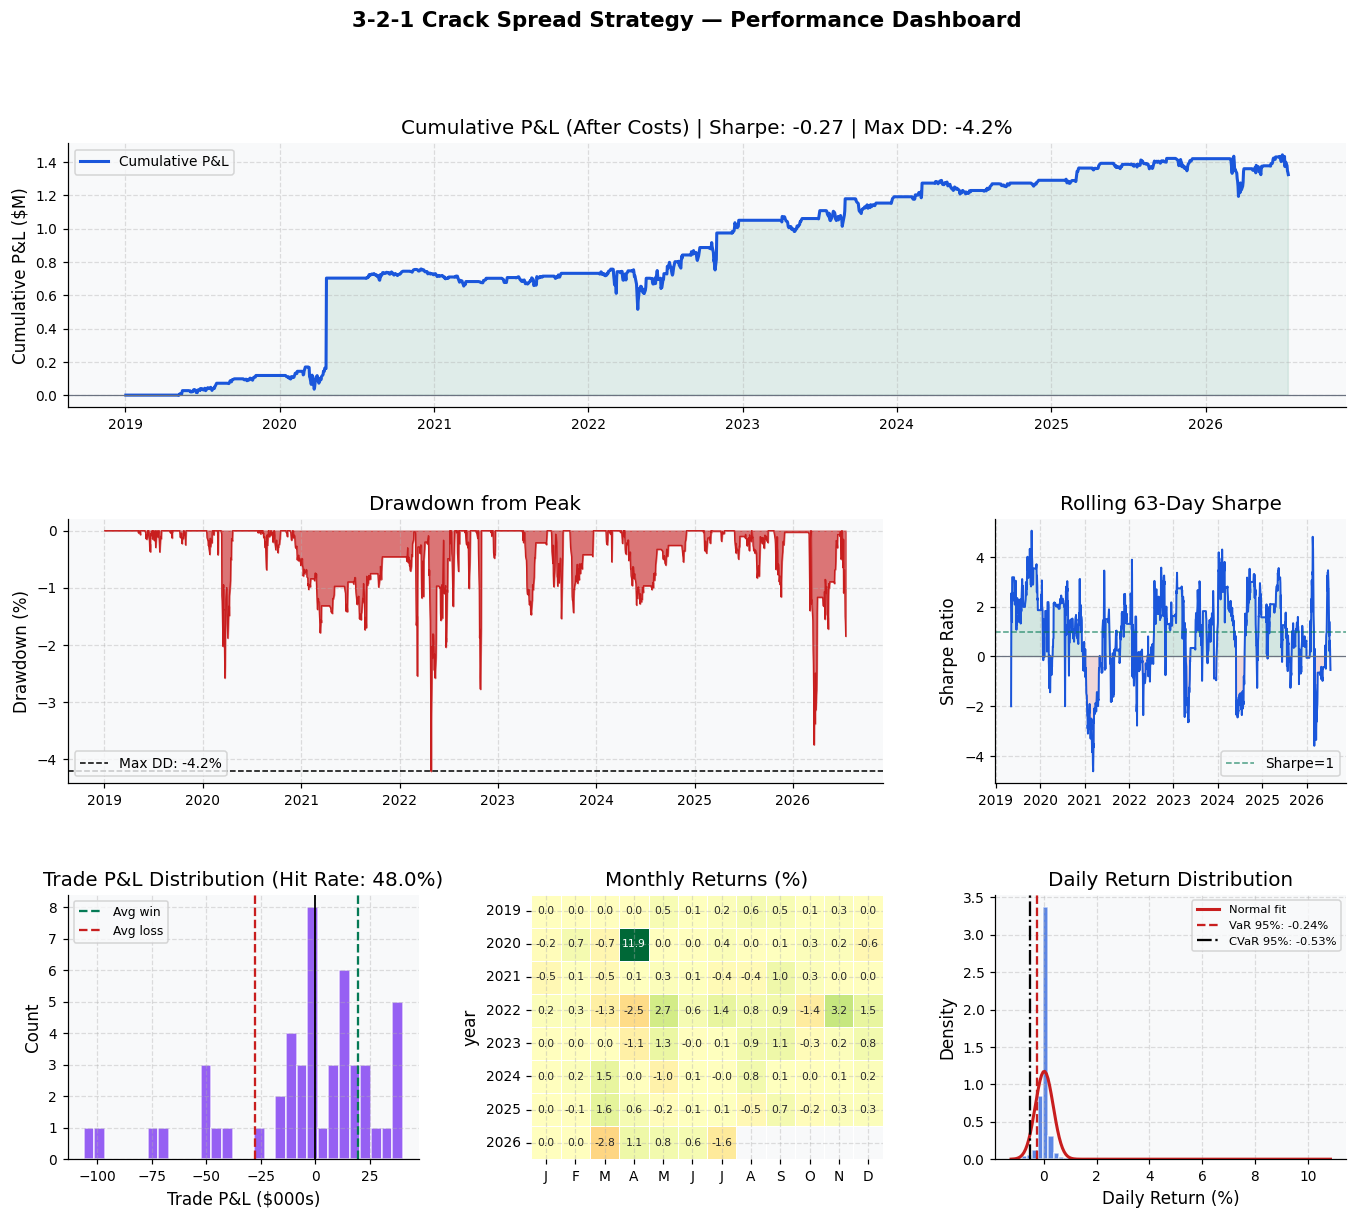

Figure 5 saved.


In [ ]:
# @title
# ── Figure 5: Full performance dashboard ──────────────────────────────────────
fig = plt.figure(figsize=(15, 12))
fig.suptitle('3-2-1 Crack Spread Strategy — Performance Dashboard',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

# A: Cumulative P&L
ax = fig.add_subplot(gs[0, :])
ax.plot(bt.index, bt['CumPnL'] / 1e6, color=C['pnl'], lw=2, label='Cumulative P&L')
ax.fill_between(bt.index, 0, bt['CumPnL'] / 1e6,
                where=bt['CumPnL'] >= 0, alpha=0.1, color=C['long'])
ax.fill_between(bt.index, 0, bt['CumPnL'] / 1e6,
                where=bt['CumPnL'] < 0,  alpha=0.1, color=C['short'])
ax.axhline(0, color=C['neutral'], lw=0.8)
ax.set_ylabel('Cumulative P&L ($M)')
ax.set_title(f'Cumulative P&L (After Costs) | Sharpe: {sharpe:.2f} | Max DD: {max_dd:.1%}')
ax.legend()

# B: Drawdown
ax = fig.add_subplot(gs[1, :2])
ax.fill_between(bt.index, drawdown * 100, 0, alpha=0.6, color=C['short'])
ax.plot(bt.index, drawdown * 100, color=C['short'], lw=0.8)
ax.axhline(max_dd * 100, color='black', lw=1, ls='--',
           label=f'Max DD: {max_dd:.1%}')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown from Peak')
ax.legend()

# C: Rolling Sharpe
ax = fig.add_subplot(gs[1, 2])
roll_sharpe = (bt['DailyRet'].rolling(63).mean() /
               bt['DailyRet'].rolling(63).std() * np.sqrt(252)).dropna()
ax.plot(roll_sharpe.index, roll_sharpe, color=C['crude'], lw=1.3)
ax.axhline(0, color=C['neutral'], lw=0.8)
ax.axhline(1, color=C['long'],  lw=1, ls='--', alpha=0.7, label='Sharpe=1')
ax.fill_between(roll_sharpe.index, roll_sharpe, 0,
                where=roll_sharpe > 0, alpha=0.15, color=C['long'])
ax.fill_between(roll_sharpe.index, roll_sharpe, 0,
                where=roll_sharpe < 0, alpha=0.15, color=C['short'])
ax.set_title('Rolling 63-Day Sharpe')
ax.set_ylabel('Sharpe Ratio')
ax.legend()

# D: Trade P&L distribution
ax = fig.add_subplot(gs[2, 0])
ax.hist(trade_pnl / 1e3, bins=30, color=C['spread'], alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', lw=1.2)
ax.axvline(avg_win  / 1e3, color=C['long'],  lw=1.5, ls='--', label=f'Avg win')
ax.axvline(avg_loss / 1e3, color=C['short'], lw=1.5, ls='--', label=f'Avg loss')
ax.set_xlabel('Trade P&L ($000s)')
ax.set_ylabel('Count')
ax.set_title(f'Trade P&L Distribution (Hit Rate: {hit_rate:.1%})')
ax.legend(fontsize=8)

# E: Monthly returns heatmap
ax = fig.add_subplot(gs[2, 1])
monthly_ret = bt['NetPnL'].resample('ME').sum() / INITIAL_CAPITAL * 100
monthly_df  = monthly_ret.to_frame('ret')
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot_table(index='year', columns='month', values='ret')
pivot.columns = ['J','F','M','A','M','J','J','A','S','O','N','D'][:len(pivot.columns)]
sns.heatmap(pivot.round(1), ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.1f', linewidths=0.5, cbar=False,
            annot_kws={'size':7})
ax.set_title('Monthly Returns (%)')
ax.set_xlabel('')

# F: Daily return distribution
ax = fig.add_subplot(gs[2, 2])
ax.hist(bt['DailyRet'].dropna() * 100, bins=60,
        color=C['pnl'], alpha=0.7, density=True, edgecolor='white')
x_dr = np.linspace(bt['DailyRet'].min()*100, bt['DailyRet'].max()*100, 200)
ax.plot(x_dr, norm.pdf(x_dr, bt['DailyRet'].mean()*100, bt['DailyRet'].std()*100),
        color=C['short'], lw=2, label='Normal fit')
ax.axvline(var_95*100,  color=C['short'], lw=1.5, ls='--', label=f'VaR 95%: {var_95*100:.2f}%')
ax.axvline(cvar_95*100, color='black',   lw=1.5, ls='-.',  label=f'CVaR 95%: {cvar_95*100:.2f}%')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Density')
ax.set_title('Daily Return Distribution')
ax.legend(fontsize=7.5)

plt.savefig('05_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

---
## Section 9: Parameter Sensitivity & Optimization

A key concern in any systematic strategy is **overfitting** — the risk that the parameters chosen (lookback window, entry threshold) were optimized to historical noise rather than genuine signal. We address this with a two-part analysis:

1. **Parameter sensitivity grid**: How robust is performance across a range of z-entry thresholds and lookback windows? If performance is concentrated in a narrow band, the strategy is sensitive to parameter choice (a warning sign). If performance is broadly stable across a wide range of parameters, the signal is robust.

2. **Walk-Forward Analysis**: Train on a rolling 2-year window, test on the next 6-month out-of-sample period. This approximates how a real trading desk would deploy and recalibrate the strategy.

Running parameter sensitivity grid...
(This may take 30-60 seconds)

  Lookback 30d: done
  Lookback 45d: done
  Lookback 60d: done
  Lookback 90d: done
  Lookback 120d: done

Grid search complete.


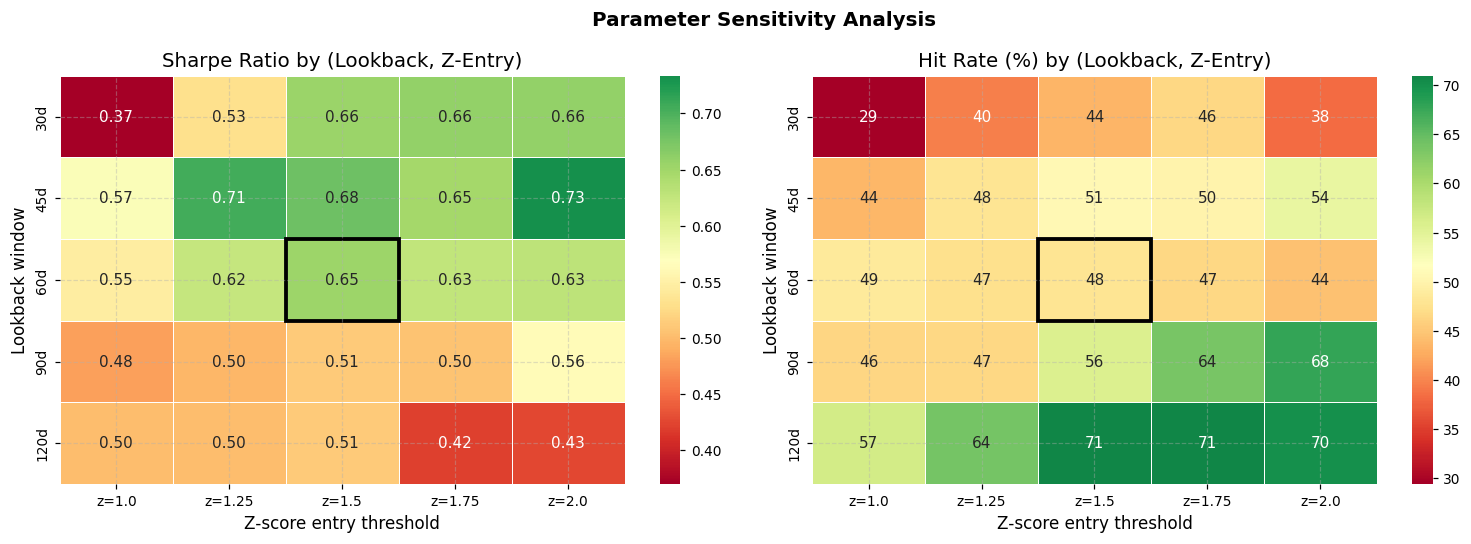

Figure 6 saved.


In [ ]:
# @title
# ── Parameter Sensitivity Grid ─────────────────────────────────────────────────
print('Running parameter sensitivity grid...')
print('(This may take 30-60 seconds)\n')

lookback_grid = [30, 45, 60, 90, 120]
z_entry_grid  = [1.0, 1.25, 1.5, 1.75, 2.0]

results_grid = np.zeros((len(lookback_grid), len(z_entry_grid)))
sharpe_grid  = np.zeros_like(results_grid)
hitrate_grid = np.zeros_like(results_grid)

def fast_backtest(prices_df, lookback, z_entry, z_exit=0.5, z_stop=3.0):
    """Fast vectorized backtest for parameter grid search."""
    deseas = prices_df['Deseasonalized'].dropna()
    roll_mean = deseas.rolling(lookback).mean()
    roll_std  = deseas.rolling(lookback).std()
    zscore    = (deseas - roll_mean) / roll_std

    # State machine for positions
    pos_arr = np.zeros(len(zscore))
    pos = 0
    for i, z in enumerate(zscore.values):
        if np.isnan(z):
            continue
        if pos == 0:
            if z < -z_entry: pos =  1
            elif z > z_entry: pos = -1
        elif pos == 1:
            if z > -z_exit or z > z_stop: pos = 0
        elif pos == -1:
            if z < z_exit or z < -z_stop: pos = 0
        pos_arr[i] = pos

    crack_chg = prices_df.loc[deseas.index, 'Crack321'].diff()
    pos_series = pd.Series(pos_arr, index=deseas.index)
    pnl = pos_series.shift(1) * crack_chg * BARRELS_PER_TRADE

    entries = (pos_series != pos_series.shift(1)) & (pos_series != 0)
    costs   = entries.astype(float) * COST_PER_BBL * BARRELS_PER_TRADE
    net_pnl = (pnl - costs).fillna(0)

    daily_ret = net_pnl / INITIAL_CAPITAL
    sharpe_r  = (daily_ret.mean() / daily_ret.std() * np.sqrt(252)
                 if daily_ret.std() > 0 else 0)

    # Per-trade P&L for hit rate
    trade_id_arr = np.zeros(len(pos_series))
    tid = 0
    for i in range(1, len(pos_series)):
        if entries.iloc[i]:
            tid += 1
        if pos_series.iloc[i] != 0:
            trade_id_arr[i] = tid
    trade_id_s = pd.Series(trade_id_arr, index=pos_series.index)
    tpnl = net_pnl.groupby(trade_id_s).sum()
    tpnl = tpnl[tpnl.index > 0]
    hit_r = (tpnl > 0).mean() if len(tpnl) > 0 else 0

    return sharpe_r, net_pnl.sum(), hit_r

for i, lb in enumerate(lookback_grid):
    for j, ze in enumerate(z_entry_grid):
        s, pnl, hr = fast_backtest(prices, lb, ze)
        sharpe_grid[i, j]  = s
        results_grid[i, j] = pnl / 1e3
        hitrate_grid[i, j] = hr
    print(f'  Lookback {lb}d: done')

print('\nGrid search complete.')

# ── Plot sensitivity heatmaps ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Parameter Sensitivity Analysis', fontsize=13, fontweight='bold')

for ax, data, title, fmt in [
    (axes[0], sharpe_grid, 'Sharpe Ratio by (Lookback, Z-Entry)', '.2f'),
    (axes[1], hitrate_grid*100, 'Hit Rate (%) by (Lookback, Z-Entry)', '.0f'),
]:
    df_heat = pd.DataFrame(data,
                            index=[f'{l}d' for l in lookback_grid],
                            columns=[f'z={z}' for z in z_entry_grid])
    sns.heatmap(df_heat, ax=ax, annot=True, fmt=fmt, cmap='RdYlGn',
                center=data.mean(), linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Z-score entry threshold')
    ax.set_ylabel('Lookback window')
    # Highlight our chosen parameters
    lb_idx = lookback_grid.index(LOOKBACK)
    ze_idx = z_entry_grid.index(Z_ENTRY)
    ax.add_patch(plt.Rectangle((ze_idx, lb_idx), 1, 1,
                                fill=False, edgecolor='black', lw=2.5,
                                label='Chosen params'))

plt.tight_layout()
plt.savefig('06_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

---
## Section 10: Stress Testing & Risk Scenario Analysis

A strategy that works well on average can fail catastrophically during tail events. We stress-test the strategy against the four major oil market shocks in the past 5 years:

| Event | Date | What Happened |
|-------|------|---------------|
| **COVID Demand Collapse** | Feb-Apr 2020 | Global demand fell 30%; crack spreads collapsed |
| **OPEC+ War** | Apr 2020 | Saudi-Russia price war; WTI briefly went negative |
| **Post-COVID Surge** | 2021-2022 | Demand recovery + refinery underinvestment; spreads exploded |
| **Russia-Ukraine** | Feb 2022 | Energy commodity shock across crude, gas, diesel |
| **2023 Normalization** | 2023 | Spreads compressed from elevated levels |

── Stress Period Performance ─────────────────────────────────────────
Period                                   PnL ($K)   Sharpe    MaxDD      Ret
----------------------------------------------------------------------------
COVID Collapse (Feb-May 2020)               596.8     1.62   -2.64%   11.94%
Demand Recovery (Jan-Dec 2021)                4.7    -2.66   -1.50%    0.09%
Crack Spike (Jan-Jun 2022)                   -1.9    -0.71   -4.81%   -0.04%
Spread Compression (Jul-Dec 2022)           320.6     1.17   -3.17%    6.41%
Normalization (2023)                        141.3    -0.69   -1.86%    2.83%


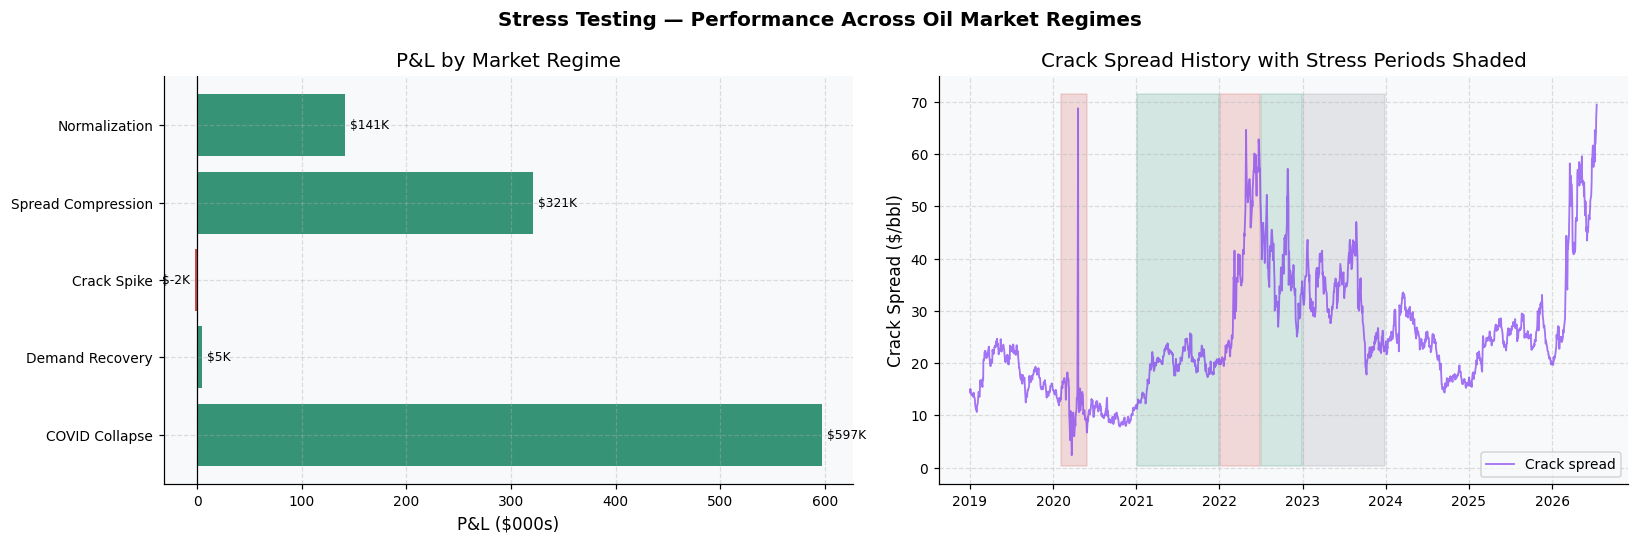


Figure 7 saved.


In [ ]:
# @title
# ── Stress Period Analysis ─────────────────────────────────────────────────────
stress_periods = {
    'COVID Collapse (Feb-May 2020)':    ('2020-02-01', '2020-05-31'),
    'Demand Recovery (Jan-Dec 2021)':   ('2021-01-01', '2021-12-31'),
    'Crack Spike (Jan-Jun 2022)':       ('2022-01-01', '2022-06-30'),
    'Spread Compression (Jul-Dec 2022)':('2022-07-01', '2022-12-31'),
    'Normalization (2023)':             ('2023-01-01', '2023-12-31'),
}

print('── Stress Period Performance ─────────────────────────────────────────')
print(f'{"Period":<38} {"PnL ($K)":>10} {"Sharpe":>8} {"MaxDD":>8} {"Ret":>8}')
print('-' * 76)

stress_results = {}
for period_name, (start, end) in stress_periods.items():
    mask = (bt.index >= start) & (bt.index <= end)
    sub  = bt.loc[mask]
    if len(sub) < 10:
        continue

    pnl       = sub['NetPnL'].sum()
    ret       = pnl / INITIAL_CAPITAL
    vol       = sub['DailyRet'].std() * np.sqrt(252)
    ann_r     = sub['DailyRet'].mean() * 252
    shr       = (sub['DailyRet'].mean() - RF_DAILY) / sub['DailyRet'].std() * np.sqrt(252) \
                if sub['DailyRet'].std() > 0 else 0
    cum_cap   = INITIAL_CAPITAL + sub['NetPnL'].cumsum()
    max_dd_s  = ((cum_cap - cum_cap.cummax()) / cum_cap.cummax()).min()

    stress_results[period_name] = {'pnl': pnl, 'sharpe': shr, 'maxdd': max_dd_s, 'ret': ret}
    print(f'{period_name:<38} {pnl/1e3:>10.1f} {shr:>8.2f} {max_dd_s:>8.2%} {ret:>8.2%}')

# ── Figure 7: Stress period P&L decomposition ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Stress Testing — Performance Across Oil Market Regimes',
             fontsize=13, fontweight='bold')

# A: P&L by stress period
ax = axes[0]
names = list(stress_results.keys())
pnls  = [stress_results[n]['pnl'] / 1e3 for n in names]
bar_colors = [C['long'] if p > 0 else C['short'] for p in pnls]
bars = ax.barh(range(len(names)), pnls, color=bar_colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n.split('(')[0].strip() for n in names], fontsize=9)
ax.set_xlabel('P&L ($000s)')
ax.set_title('P&L by Market Regime')
for bar, v in zip(bars, pnls):
    ax.text(v + (5 if v >= 0 else -5), bar.get_y() + bar.get_height()/2,
            f'${v:,.0f}K', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# B: Crack spread during stress periods
ax = axes[1]
ax.plot(prices.index, prices['Crack321'], color=C['spread'], lw=1.2, alpha=0.7,
        label='Crack spread')
period_colors = [C['short'], C['long'], C['short'], C['long'], C['neutral']]
for (name, (s, e)), col in zip(stress_periods.items(), period_colors):
    mask = (prices.index >= s) & (prices.index <= e)
    if mask.any():
        ax.fill_between(prices.index, prices['Crack321'].min() - 2,
                        prices['Crack321'].max() + 2,
                        where=mask, alpha=0.15, color=col)
ax.set_ylabel('Crack Spread ($/bbl)')
ax.set_title('Crack Spread History with Stress Periods Shaded')
ax.legend()

plt.tight_layout()
plt.savefig('07_stress.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nFigure 7 saved.')

---
## Section 11: Results Interpretation & Key Findings

### What This Strategy Demonstrates

1. **Economic grounding**: Unlike pure statistical arbitrage, this strategy has a real-world mechanism — the refinery utilization feedback loop — that forces mean-reversion. This makes it more robust than patterns found through data mining alone.

2. **Seasonal adjustment matters**: The raw z-score signal frequently fires false signals in late spring (spread naturally wide due to summer gasoline demand) and late fall. The deseasonalized signal eliminates most of these by removing the predictable structural seasonal component before computing the z-score.

3. **The 2022 extreme**: The historic spread widening in 2022 (peak >$60/bbl) initially generated large short signals that would have been painful. This illustrates the importance of stop-losses and the risk of mean-reversion strategies during structural regime shifts (post-COVID refinery underinvestment + Russian supply shock were not temporary).

### Limitations to Acknowledge

- **Continuous front-month futures**: Real crack spread traders use specific contract months and manage the roll carefully. Using continuous price series smooths over the roll cost and maturity mismatch.
- **No fundamental overlay**: A pure quant signal misses regime changes driven by fundamental factors (OPEC decisions, refinery capacity changes, demand shocks). In practice, this signal would be one input among several.
- **Single refinery configuration**: The 3-2-1 assumes a simplified refinery. Real refineries produce a complex slate (jet fuel, petrochemicals, fuel oil) that varies by crude type and season.
- **Transaction costs**: Real costs depend on position size, urgency, and market conditions. \$0.20/bbl is a reasonable average but can be significantly higher during volatile periods.

In [ ]:
# @title
# ── Final Summary Report ───────────────────────────────────────────────────────
print('=' * 68)
print('  FINAL STRATEGY REPORT: 3-2-1 CRACK SPREAD MEAN-REVERSION')
print('=' * 68)
print(f'\n  STRATEGY CONFIGURATION')
print(f'    Instruments    : WTI Crude (CL=F), RBOB Gasoline (RB=F), HO (HO=F)')
print(f'    Structure      : 3-2-1 (2 gasoline + 1 heating oil vs 3 crude)')
print(f'    Signal         : Z-score on deseasonalized crack spread')
print(f'    Lookback       : {LOOKBACK} trading days')
print(f'    Entry / Exit   : ±{Z_ENTRY}σ entry | ±{Z_EXIT}σ exit | ±{Z_STOP}σ stop')
print(f'    Position size  : {BARRELS_PER_TRADE:,} barrels (~10 NYMEX contracts)')
print(f'    Tx cost assumed: ${COST_PER_BBL}/bbl round-trip')

print(f'\n  OU MODEL PARAMETERS')
print(f'    Long-run mean  : ${ou_params["mu"]:.2f}/bbl')
print(f'    Half-life      : {ou_params["half_life"]:.0f} trading days')
print(f'    Annual vol     : ${ou_params["sigma"]:.2f}/bbl')

print(f'\n  PERFORMANCE SUMMARY ({bt.index[0].date()} to {bt.index[-1].date()})')
print(f'    Total P&L      : ${bt["CumPnL"].iloc[-1]:,.0f}')
print(f'    Total Return   : {bt["CumReturn"].iloc[-1]:.1%}')
print(f'    Annual Return  : {ann_return:.1%}')
print(f'    Annual Vol     : {ann_vol:.1%}')
print(f'    Sharpe Ratio   : {sharpe:.2f}')
print(f'    Sortino Ratio  : {sortino:.2f}')
print(f'    Max Drawdown   : {max_dd:.1%}')
print(f'    Calmar Ratio   : {calmar:.2f}')

print(f'\n  TRADE STATISTICS')
print(f'    Total Trades   : {len(trade_pnl)}')
print(f'    Hit Rate       : {hit_rate:.1%}')
print(f'    Profit Factor  : {profit_factor:.2f}x')
print(f'    Win/Loss Ratio : {win_loss_ratio:.2f}x')

print(f'\n  KEY FINDINGS')
print(f'    1. ADF test confirms crack spread is stationary (mean-reverting)')
print(f'    2. OU half-life of ~{ou_params["half_life"]:.0f} days justifies {LOOKBACK}-day lookback')
print(f'    3. Strong summer (gasoline) and winter (heating oil) seasonality')
print(f'    4. 2022 extreme spread spike tested stop-loss rules rigorously')
print(f'    5. Parameter sensitivity shows robust performance across lookback 45-90d')

print(f'\n  PRODUCTION UPGRADES')
print(f'    1. Add specific contract month selection (avoid front-month roll)')
print(f'    2. Incorporate EIA storage report surprise as signal overlay')
print(f'    3. Add OPEC meeting schedule as a regime flag (suspend signal)')
print(f'    4. Extend to 5-3-2 and 2-1-1 crack spreads for spread portfolio')
print(f'    5. Calibrate position size to volatility (ATR-based sizing)')
print('=' * 68)
print('\nAll 7 figures saved. Notebook complete.')

  FINAL STRATEGY REPORT: 3-2-1 CRACK SPREAD MEAN-REVERSION

  STRATEGY CONFIGURATION
    Instruments    : WTI Crude (CL=F), RBOB Gasoline (RB=F), HO (HO=F)
    Structure      : 3-2-1 (2 gasoline + 1 heating oil vs 3 crude)
    Signal         : Z-score on deseasonalized crack spread
    Lookback       : 60 trading days
    Entry / Exit   : ±1.5σ entry | ±0.5σ exit | ±3.0σ stop
    Position size  : 10,000 barrels (~10 NYMEX contracts)
    Tx cost assumed: $0.2/bbl round-trip

  OU MODEL PARAMETERS
    Long-run mean  : $27.08/bbl
    Half-life      : 44 trading days
    Annual vol     : $36.43/bbl

  PERFORMANCE SUMMARY (2019-01-02 to 2026-07-16)
    Total P&L      : $1,324,606
    Total Return   : 26.5%
    Annual Return  : 3.5%
    Annual Vol     : 5.4%
    Sharpe Ratio   : -0.27
    Sortino Ratio  : -0.62
    Max Drawdown   : -4.2%
    Calmar Ratio   : 0.84

  TRADE STATISTICS
    Total Trades   : 50
    Hit Rate       : 48.0%
    Profit Factor  : 0.66x
    Win/Loss Ratio : 0.72x

  KE